In [1]:
import qutip
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## Hamiltonian / Master Equation Parameters

In [2]:
''' Hamiltonian / Master parameters '''
w_s = 7.0 * 1e9 * 2 * np.pi       # superconducting resonator frequency (7 GHz)
w_q  = 5.5 * 1e9 * 2 * np.pi      # qubit frequency (5.5 GHz)
w_a = w_q - 13 * 1e6 * 2 * np.pi  # HBAR mode frequency (5.5 GHz - 13 MHz)

kappa_s = 200 * 1e3 * 2 * np.pi   # superconducting resonator kappa (200 kHz)
kappa_a = w_a / 1e6               # acoustic mode kappa (~5 kHz)
gamma_1  = 0.0                    # give no intrinsic T1 to qubit for now 

g_qs = 150e6 * 2 * np.pi          # qubit-(superconducting)resonator coupling (150 MHz)
g_qa = 1e6   * 2 * np.pi          # qubit-(acoustic)resonator coupling (1 MHz)

## Define the sizes of the Hilbert Spaces

We can keep the superconducting and acoustic resonators' Hilbert spaces to dim$(\mathcal{H})$ = 2 because we are initializing our state as $|\Psi(0)\rangle = |0,0,e\rangle$ and since we've taken the rotating wave approximation, all interactions in the Hamiltonian are excitation conserving (e.g., we can only have one excitation present at any time). Moreover, we've taken T = 0, so there will be no stimulated absorption adding photons/phonons to the system. 

In [3]:
''' Hilbert Spaces'''
N_s = 2 # Hilbert Space size of superconducting resonator
N_a = 2 # Hilbert Space size of acoustic resonator
N_q = 2 # Hilbert Space size of qubit, of course, = 2

## Define thermal excitations 

We take the bath to be at T = 0, hence we expect no thermal photons or phonons

In [4]:
''' thermal excitations, we take temperature to be 0, so no thermal photons/phonons''' 
thermal_photons = 0.0 # for superconducting resonator
thermal_phonons = 0.0 # for acoustic resonator

## Define creation & annhiliation operators

* $\hat{a} \equiv$ annhilation operator of superconducting resonator excitations (photons)
* $\hat{b} \equiv$ annhilation operator of acoustic resonator excitations (phonons)
* $\hat{\sigma}_- \equiv$ lowering operator of qubit

## Also define the observable(s) of interest

In this case, we are looking for the qubit excited state probability:
$P_{ee}(t) = \langle \Psi |\hat{\sigma}_+\hat{\sigma}_-|\Psi\rangle = \langle \Psi | e \rangle\langle e | \Psi \rangle = |\langle e|\Psi \rangle|^2 $ 

or in terms of the density matrix, $P_{ee}(t) = Tr[\hat{\rho}\hat{\sigma}_+\hat{\sigma}_-]$

In [5]:
''' define creation / annihilation operators ''' 
a = qutip.tensor(qutip.destroy(N_s), qutip.qeye(N_a), qutip.qeye(2))
b = qutip.tensor(qutip.qeye(N_s), qutip.destroy(N_a), qutip.qeye(2))
sm = qutip.tensor(qutip.qeye(N_s), qutip.qeye(N_a), qutip.destroy(2))

# this is the operator we want the expectation value of P_ee(t) = <e|σ+σ-|e> = <e|e><e|e> = |e|^2
# or in more appropiately in terms of density matrcies P_ee(t) = Tr[𝞺|e><e|]
Pee_op = sm.dag() * sm

## Define collapse operators

Controls non-Hermitian evolution of our system, in this case, the superconducting & acoustic resonators leaking information to the environment

In [6]:
''' collapse operators for decay '''
c_ops = []

## loss of superconducting resonator quanta ##
rate = kappa_s * (1 + thermal_photons) #  if thermal photons present, we would get stimulated emission increasing effective rate
if rate > 0:
    c_ops.append(np.sqrt(rate) * a)

## thermal excitation of superconducting resonator photons ## --> will be 0 because we take T = 0
rate = kappa_s * thermal_photons
if rate > 0:
    c_ops.append(np.sqrt(rate) * a.dag())

## loss of acoustic resonator quanta ##
rate = kappa_a * (1 + thermal_phonons)
if rate > 0:
    c_ops.append(np.sqrt(rate) * b)

## thermal excitation of acoustic resonator phonons ##
rate = kappa_a * thermal_phonons
if rate > 0:
    c_ops.append(np.sqrt(rate) * b.dag())

## qubit decay ##
if gamma_1 > 0:
    c_ops.append(np.sqrt(gamma_1) * sm)

## Define Hamiltonian 

Qubit coupled to two indepedent quantum oscillators ("double Jaynes-Cummings")

$\hat{H} = \hbar\omega_q\hat{\sigma}_+\hat{\sigma}_- + \hbar\omega_s\hat{a}^\dagger\hat{a} + \hbar\omega_a\hat{b}^\dagger\hat{b} + g_{qs}(\hat{\sigma}_+\hat{a} + \hat{a}^\dagger\hat{\sigma}_-) + g_{qa}(\hat{\sigma}_+\hat{b} + \hat{b}^\dagger\hat{\sigma}_-)$

## Also define our initial state

Start our system with no photons in the superconducting resonator, no phonons in the acoustic resonator, and our qubit in the excited state.

$|\Psi(0)\rangle = |0,0,e\rangle$

In [7]:
''' double JC Hamiltonian '''
H = (w_s * a.dag() * a + w_a * b.dag() * b + w_q  * sm.dag() * sm 
     + g_qs * (a.dag() * sm + a * sm.dag()) + g_qa * (b.dag() * sm + b * sm.dag()))

''' initial state |0,0,e> '''
psi0 = qutip.tensor(qutip.basis(N_s, 0),qutip.basis(N_a, 0),qutip.basis(2, 1))

## Solve the Master Equation ##

$\dot{\hat{\rho}} = \frac{1}{i\hbar}[\hat{H},\hat{\rho}] + \kappa_s\mathcal{D}[\hat{a}]\hat{\rho} + \kappa_a\mathcal{D}[\hat{b}]\hat{\rho}$

In [8]:
time = np.linspace(0,200*1e-6,1001) # 200 µs

''' solve master equation '''
options = {"nsteps": 100000,"max_step": 1e-11,}
result = qutip.mesolve(H, psi0, time, c_ops=c_ops, e_ops=[Pee_op], options=options)
Pee = result.expect[0]

## Plot $P_{ee}(t)$ and fit to exponential decay function to estimate $T_1^{Purcell}$

In [9]:
def exp(x,A,tau,b):
    return A*np.exp(-x/tau) + b

T1 =  61.435170546376575


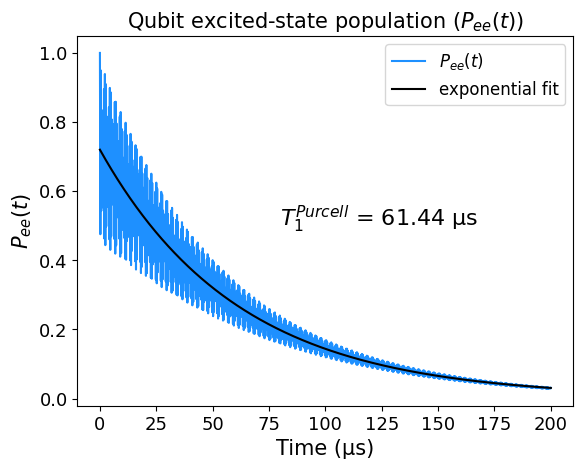

In [10]:
fig,ax = plt.subplots()

## P_ee(t) ##
plt.plot(time * 1e6, Pee,label = r"$P_{ee}(t)$",color = "dodgerblue")

## exponential fit & get T_1^Purcell ##
p,c = curve_fit(exp,time, Pee)
Purcell_limited_T1 = np.round(p[1]*1e6,2)
plt.plot(time*1e6,exp(time,*p),label = "exponential fit",color='black')
plt.text(80,0.5,r"$T_1^{Purcell}$" + " = {} µs".format(Purcell_limited_T1),fontsize = 16)
print("T1 = ",p[1]*1e6)

plt.xlabel("Time (µs)",fontsize = 15)
plt.ylabel(r"$P_{ee}(t)$",fontsize = 15)
plt.title(r"Qubit excited-state population ($P_{ee}(t)$)",fontsize = 15)
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.legend(fontsize = 12)
plt.show()
#plt.savefig("Pee_doubleJC.pdf")